In [ ]:
!pip install pandas 
#Sempre
!pip install matplotlib 
#Ler/Criar gráficos (seaborn tbm)
!pip install numpy
#Cálculos matemáticos

In [1]:
# Importação das Bibliotecas neecssárias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Carregar o arquivo com os dados brutos da fábrica
dataset = pd.read_csv(r"C:\Users\julia_vansuita\Downloads\Nova pasta\Nova pasta\dados_automacao_weg_bruto.csv")

#Visulizar as primeiras linhas(dataset.head)
print("~~~ Primeiras Linhas do Dataset ~~~")
dataset.head()

~~~ Primeiras Linhas do Dataset ~~~


,ID_EQUIP_CONFUSO,TEMP_VAL_RAW,PRES_PSI_RAW,STATUS_TXT,OP_GENERO_ERR,CONS_KWH_VAL
0,WEG-AUT-1000,80.415499,5.953804,Ativo,M,143.638137
1,WEG-AUT-1001,73.748225,8.526058,Ativo,F,119.283011
2,WEG-AUT-1002,82.000730,6.229241,Manutenção,M,109.098388
3,WEG-AUT-1003,91.191813,6.522981,Ativo,F,106.835740
4,WEG-AUT-1004,72.741390,4.435769,Ativo,M,124.990790


In [3]:
#Verificar o tamanho do dataset (dataset.shape) | indica 2150 linhas e 6 colunas.
print("\n~~~ Primeiras Linhas do Dataset Bruto ~~~")
print(dataset.shape)


~~~ Primeiras Linhas do Dataset Bruto ~~~
(2150, 6)


In [4]:
#Verificar o tamanho do dataset (dataset.head()) | Exibe as primeiras 5 linhas.
print("\n~~~ Primeiras Linhas do Dataset Bruto ~~~")
print(dataset.head())


~~~ Primeiras Linhas do Dataset Bruto ~~~
  ID_EQUIP_CONFUSO  TEMP_VAL_RAW  PRES_PSI_RAW  STATUS_TXT OP_GENERO_ERR  \
0     WEG-AUT-1000     80.415499      5.953804       Ativo             M   
1     WEG-AUT-1001     73.748225      8.526058       Ativo             F   
2     WEG-AUT-1002     82.000730      6.229241  Manutenção             M   
3     WEG-AUT-1003     91.191813      6.522981       Ativo             F   
4     WEG-AUT-1004     72.741390      4.435769       Ativo             M   

   CONS_KWH_VAL  
0    143.638137  
1    119.283011  
2    109.098388  
3    106.835740  
4    124.990790  


In [5]:
#Alterar nomes das colunas
dataset.columns = ['id', 'temperatura', 'pressao', 'status', 'genero', 'consumo_kwh']

#Validar a alteração
dataset.head()

#Centralizar títulos nas respectivas colunas
dataset.head().style.set_table_styles([
    {'selector': 'th.col_heading', 'props': [('text-align', 'center')]}])

,id,temperatura,pressao,status,genero,consumo_kwh
0,WEG-AUT-1000,80.415499,5.953804,Ativo,M,143.638137
1,WEG-AUT-1001,73.748225,8.526058,Ativo,F,119.283011
2,WEG-AUT-1002,82.000730,6.229241,Manutenção,M,109.098388
3,WEG-AUT-1003,91.191813,6.522981,Ativo,F,106.835740
4,WEG-AUT-1004,72.741390,4.435769,Ativo,M,124.990790


In [6]:
#Agrupar e explorar a coluna de Status
grupado_status = dataset.groupby(['status']).size()
print("~~~ Agrupamento por Status ~~~")
print(grupado_status)

~~~ Agrupamento por Status ~~~
status
Ativo         1527
Manutenção     403
Ocioso         220
dtype: int64


In [7]:
#Agrupamento por Gênero (feito solo)
grupado_genero = dataset.groupby(['genero']).size()
print("~~~ Agrupamento por Gênero ~~~")
print(grupado_genero)

~~~ Agrupamento por Gênero ~~~
genero
F     799
M    1351
dtype: int64


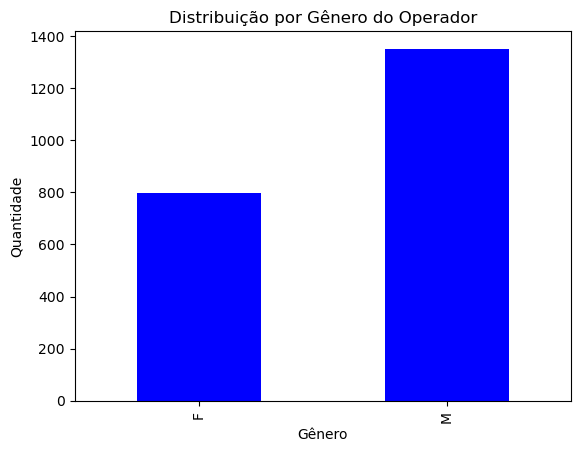

In [8]:
#Gerar o gráfico de barras na cor azul para a variável gênero
grupado_genero.plot.bar(color='blue')
plt.title('Distribuição por Gênero do Operador')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

In [9]:
print("~~~ Resumo estatístico para identificar desvios e anomalias numéricas ~~~")
dataset.describe()

~~~ Resumo estatístico para identificar desvios e anomalias numéricas ~~~


,temperatura,pressao,consumo_kwh
count,2105.000000,2100.000000,2150.000000
mean,146.289206,6.466018,120.237563
std,834.958013,3.941850,14.895532
min,41.166693,1.989315,61.163996
25%,68.714655,5.225650,110.544661
50%,75.657826,6.200258,120.296560
75%,82.518021,7.150509,130.093832
max,9999.000000,55.000000,170.660744


In [10]:
# Contamos os valores NAN por coluna
print("~~~ Valores NAN por coluna ~~~")
print(dataset.isnull().sum())

~~~ Valores NAN por coluna ~~~
id              0
temperatura    45
pressao        50
status          0
genero          0
consumo_kwh     0
dtype: int64


In [11]:
# Total de NAs no dataset completo
print (f"\nTotal de NAs inicial: {dataset.isna().sum().sum()}")


Total de NAs inicial: 95


In [12]:
# Calcular a mediana da pressão
mediana_pressao = dataset['pressao'].median()
print(mediana_pressao)

6.200258402441996


In [16]:
# Substituir os valores NAN pela mediana
dataset['pressao'] = dataset['pressao'].fillna(mediana_pressao)

In [18]:
# Visualizar linhas com dados fora do domínio
print("~~~ Registros Fora do Domínio (Temperatura = 9999) ~~~")
print (dataset[dataset['temperatura'] == 9999.0])

~~~ Registros Fora do Domínio (Temperatura = 9999) ~~~
                id  temperatura   pressao      status genero  consumo_kwh  \
19    WEG-AUT-1019       9999.0  6.852902       Ativo      M    98.529677   
66    WEG-AUT-1066       9999.0  5.588592       Ativo      F   115.643378   
71    WEG-AUT-1071       9999.0  5.293441       Ativo      M   104.716951   
133   WEG-AUT-1133       9999.0  4.826368       Ativo      F   114.574142   
247   WEG-AUT-1247       9999.0  4.794460       Ativo      M    99.153298   
372   WEG-AUT-1372       9999.0  6.714474       Ativo      M   125.385826   
600   WEG-AUT-1600       9999.0  8.657666       Ativo      F    98.637486   
846   WEG-AUT-1846       9999.0  6.560854  Manutenção      M   127.904721   
878   WEG-AUT-1878       9999.0  5.486271       Ativo      M   116.011199   
1037  WEG-AUT-2037       9999.0  7.451177  Manutenção      F   133.272639   
1377  WEG-AUT-2377       9999.0  9.095069       Ativo      M   124.534844   
1552  WEG-AUT-2552   

In [19]:
#Calcular a mediana ignorando os valores espúrios e nulos
mediana_temperatura = dataset[(dataset['temperatura'] != 9999.0) & (dataset['temperatura'].notnull())]['temperatura'].median()
print(mediana_temperatura)

75.50713005276046


In [22]:
# Substituir os dados fora do domínio por NaN e depois preencher tudo com a mediana
dataset['temperatura'] = dataset['temperatura'].replace(9999.0, np.nan)
dataset['temperatura'] = dataset['temperatura'].fillna(mediana_temperatura)

In [25]:
# Verificamos se os NANs foram totalmente eliminados
print("\n~~~ Verificação Final de NANs por Coluna ~~~")
print(dataset.isnull().sum())
print(f"Total de NANs atual após tratamentos: {dataset.isna().sum().sum()}")


~~~ Verificação Final de NANs por Coluna ~~~
id             0
temperatura    0
pressao        0
status         0
genero         0
consumo_kwh    0
pressoa        0
dtype: int64
Total de NANs atual após tratamentos: 0


In [26]:
# Procurando por duplicados com base na coluna ID
duplicados_id = dataset[dataset.duplicated(['id'], keep=False)]
print(f"Total de linhas duplicadas encontradas por ID: {len(duplicados_id)}")

Total de linhas duplicadas encontradas por ID: 120


In [27]:
# Excluímos as linhas duplicados mantendo apenas a primeira ocorrência
dataset.drop_duplicates(subset=['id'], keep='first', inplace=True)
print("Duplicados removidos com sucesso!")

Duplicados removidos com sucesso!


In [28]:
# Definir um limite técnico para a pressão e substituir outliers pela mediana
dataset.loc[dataset['pressao'] > 20.0, 'pressao'] = mediana_pressao

In [33]:
# Visualizar a estrutura final do dataset tratatdo
print("\n~~~ Dataset.Head Tratado ~~~\n")
print(dataset.head())


~~~ Dataset.Head Tratado ~~~

             id  temperatura   pressao      status genero  consumo_kwh  \
0  WEG-AUT-1000    80.415499  5.953804       Ativo      M   143.638137   
1  WEG-AUT-1001    73.748225  8.526058       Ativo      F   119.283011   
2  WEG-AUT-1002    82.000730  6.229241  Manutenção      M   109.098388   
3  WEG-AUT-1003    91.191813  6.522981       Ativo      F   106.835740   
4  WEG-AUT-1004    72.741390  4.435769       Ativo      M   124.990790   

    pressoa  
0  5.953804  
1  8.526058  
2  6.229241  
3  6.522981  
4  4.435769  


In [35]:
# Exibir quantas linhas e colunas ficarão sem dados duplicados
print("\n~~~ Dataset.Shape Final ~~~\n")
print(dataset.shape)


~~~ Dataset.Shape Final ~~~

(2090, 7)


In [36]:
import os

diretorio = r"C:\Users\julia_vansuita\Documents\dados_automação_weg_limpo.csv"

nome_arq = "dados_automação_weg_limpo.csv"

caminho = os.path.join(diretorio, nome_arq)

print(f"Arquivo salvo em: \n{caminho}")

Arquivo salvo em: 
C:\Users\julia_vansuita\Documents\dados_automação_weg_limpo.csv\dados_automação_weg_limpo.csv
